In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

FIG_DIR_ROOT = PROJECT_ROOT / "figures" / "arctic_amplification/50n"

In [15]:
import os, glob
from pathlib import Path
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

In [20]:
class AAMonthlyBoxplotPlotter:
    """
    Make a monthly AA boxplot like the reference figure:

      • Boxes = model ensemble (per-member monthly AA means)
      • Red dot = observation (ERA5) monthly AA
      • Top label = fraction of windows with AA ≥ gate (%, mean over members)

    Reads the compact NetCDF written by ArcticAAMonthlyMetrics.save_netcdf_metrics:
      - aa_mean(ens, month)       # per-member monthly mean AA
      - obs_aa(month)             # ERA5
      - frac_AA_ge2(month)        # %
      - coords: month (1..12, 13 for Ann) and month_name ("Jan"..,"Ann")

    Minimal:
        plotter = AAMonthlyBoxplotPlotter(fig_dir=OUT_DIR)
        plotter.plot_from_nc(f"{OUT_DIR}/AA_monthly_metrics_1979-2018.nc",
                             out_name="AA_boxpanel.center.pdf")
    """

    def __init__(self, *, fig_dir=".", fontz=12, dpi=300):
        self.fig_dir = fig_dir
        self.fontz = int(fontz)
        self.dpi = int(dpi)

        plt.rcParams.update({
            "font.size": self.fontz,
            "axes.titlesize": self.fontz * 1.05,
            "axes.labelsize": self.fontz,
            "xtick.labelsize": self.fontz,
            "ytick.labelsize": self.fontz,
            "legend.fontsize": self.fontz * 0.95,
        })

    # ---------- I/O ----------
    @staticmethod
    def _load_nc(path) -> xr.Dataset:
        ds = xr.open_dataset(path)
        # sanity
        for v in ("aa_mean", "obs_aa", "frac_AA_ge2"):
            if v not in ds:
                raise KeyError(f"Expected variable '{v}' not found in {path}")
        return ds

    # ---------- core prep ----------
    @staticmethod
    def _prep_from_ds(ds):
        """Return boxes(list[np.ndarray]), obs(list[float]), pct(list[float]), labels(list[str])."""
        # determine order and names
        if "month_name" in ds.coords:
            labels = [str(x) for x in ds["month_name"].values.tolist()]
        else:
            # fallback if names missing
            base = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
            labels = base + (["Ann"] if (ds.dims.get("month", 0) == 13) else [])

        # pull arrays month-by-month in dataset order
        aa2d = np.asarray(ds["aa_mean"].values, float)   # shape (nEns, nMon)
        obs1d = np.asarray(ds["obs_aa"].values, float)   # shape (nMon,)
        pct1d = np.asarray(ds["frac_AA_ge2"].values, float)

        # split into lists for matplotlib.boxplot
        boxes = [aa2d[:, j][np.isfinite(aa2d[:, j])] for j in range(aa2d.shape[1])]
        obs   = [float(obs1d[j]) if np.isfinite(obs1d[j]) else np.nan for j in range(obs1d.size)]
        pct   = [float(pct1d[j]) if np.isfinite(pct1d[j]) else np.nan for j in range(pct1d.size)]
        return boxes, obs, pct, labels

    # ---------- plotting ----------
    def plot_from_nc(
        self,
        nc_path: str,
        *,
        out_name="AA_boxpanel.pdf",
        ylim=(0.0, 6.0),
        show_grid=True,
        show_legend=True,
        median_color="#e67e22",     # orange-ish median
        box_linewidth=1.2,
        whisker_width=1.0,
        cap_width=1.0,
        dot_size=28,
        legend_loc="bottom",        # "bottom" | any Matplotlib loc string (e.g., "best","upper right")
        whisker_percentiles=(5, 95),
        pct_y_offset=0.04,          # fraction of y-span below top
    ):
        ds = self._load_nc(nc_path)
        boxes, obs, pct, labels = self._prep_from_ds(ds)

        nmon = len(labels)
        fig, ax = plt.subplots(figsize=(max(7.5, 0.6*nmon), 3.8), dpi=self.dpi)

        bp = ax.boxplot(
            boxes,
            positions=np.arange(1, nmon+1),
            widths=0.6,
            patch_artist=False,
            whis=whisker_percentiles,   # whiskers = given percentiles
            showfliers=False,            # keep outliers (white dots) like your figure
        )

        # ---- style: black lines; orange medians ----
        for line in ["boxes", "whiskers", "caps"]:
            for l in bp[line]:
                l.set_color("black")
                l.set_linewidth(
                    box_linewidth if line == "boxes"
                    else (whisker_width if line == "whiskers" else cap_width)
                )
        for m in bp["medians"]:
            m.set_color(median_color)
            m.set_linewidth(1.4)

        # ---- ERA5 red dots ----
        xs = np.arange(1, nmon + 1)
        obs_handle = ax.scatter(xs, obs, s=dot_size, color="red", zorder=3, label="Observations")

        # ---- axes, grid, labels ----
        ax.set_xlim(0.5, nmon + 0.5)
        ax.set_ylim(*ylim)
        ax.set_xticks(xs)
        ax.set_xticklabels(labels)
        ax.set_ylabel("Arctic amplification")
        if show_grid:
            ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

        # ---- % labels above each box ----
        y0, y1 = ax.get_ylim()
        y_span = y1 - y0
        y_text = y1 - pct_y_offset * y_span
        for i, p in enumerate(pct, start=1):
            if np.isfinite(p):
                ax.text(i, y_text, f"{p:.0f}%", ha="center", va="top", fontsize=self.fontz * 0.95)

        # ---- vertical divider before "Ann" (if present) ----
        norm_labels = [lbl.lower().capitalize() for lbl in labels]
        if "Ann" in norm_labels:
            ax.axvline(x=norm_labels.index("Ann") + 0.5, color="gray", lw=1.2, ls="--", alpha=0.7)

        # ---- legend placement ----
        if show_legend:
            if str(legend_loc).lower() == "bottom":
                # bottom-centered outside the axes
                fig.legend(handles=[obs_handle], loc="lower center", bbox_to_anchor=(0.5, -0.05),
                           ncol=1, frameon=True)
                fig.tight_layout(rect=[0, 0.07, 1, 1])  # leave space for legend
            else:
                ax.legend(handles=[obs_handle], loc=legend_loc, frameon=True)
                fig.tight_layout()

        else:
            fig.tight_layout()

        Path(self.fig_dir).mkdir(parents=True, exist_ok=True)
        out_path = os.path.join(self.fig_dir, out_name)
        fig.savefig(out_path, bbox_inches="tight")
        print(f"[OK] saved {out_path}")
        return fig, ax



[OK] saved ./figures/AA_monthly_boxpanel.center.pdf
[OK] Figure written to: ./figures/AA_monthly_boxpanel.center.pdf


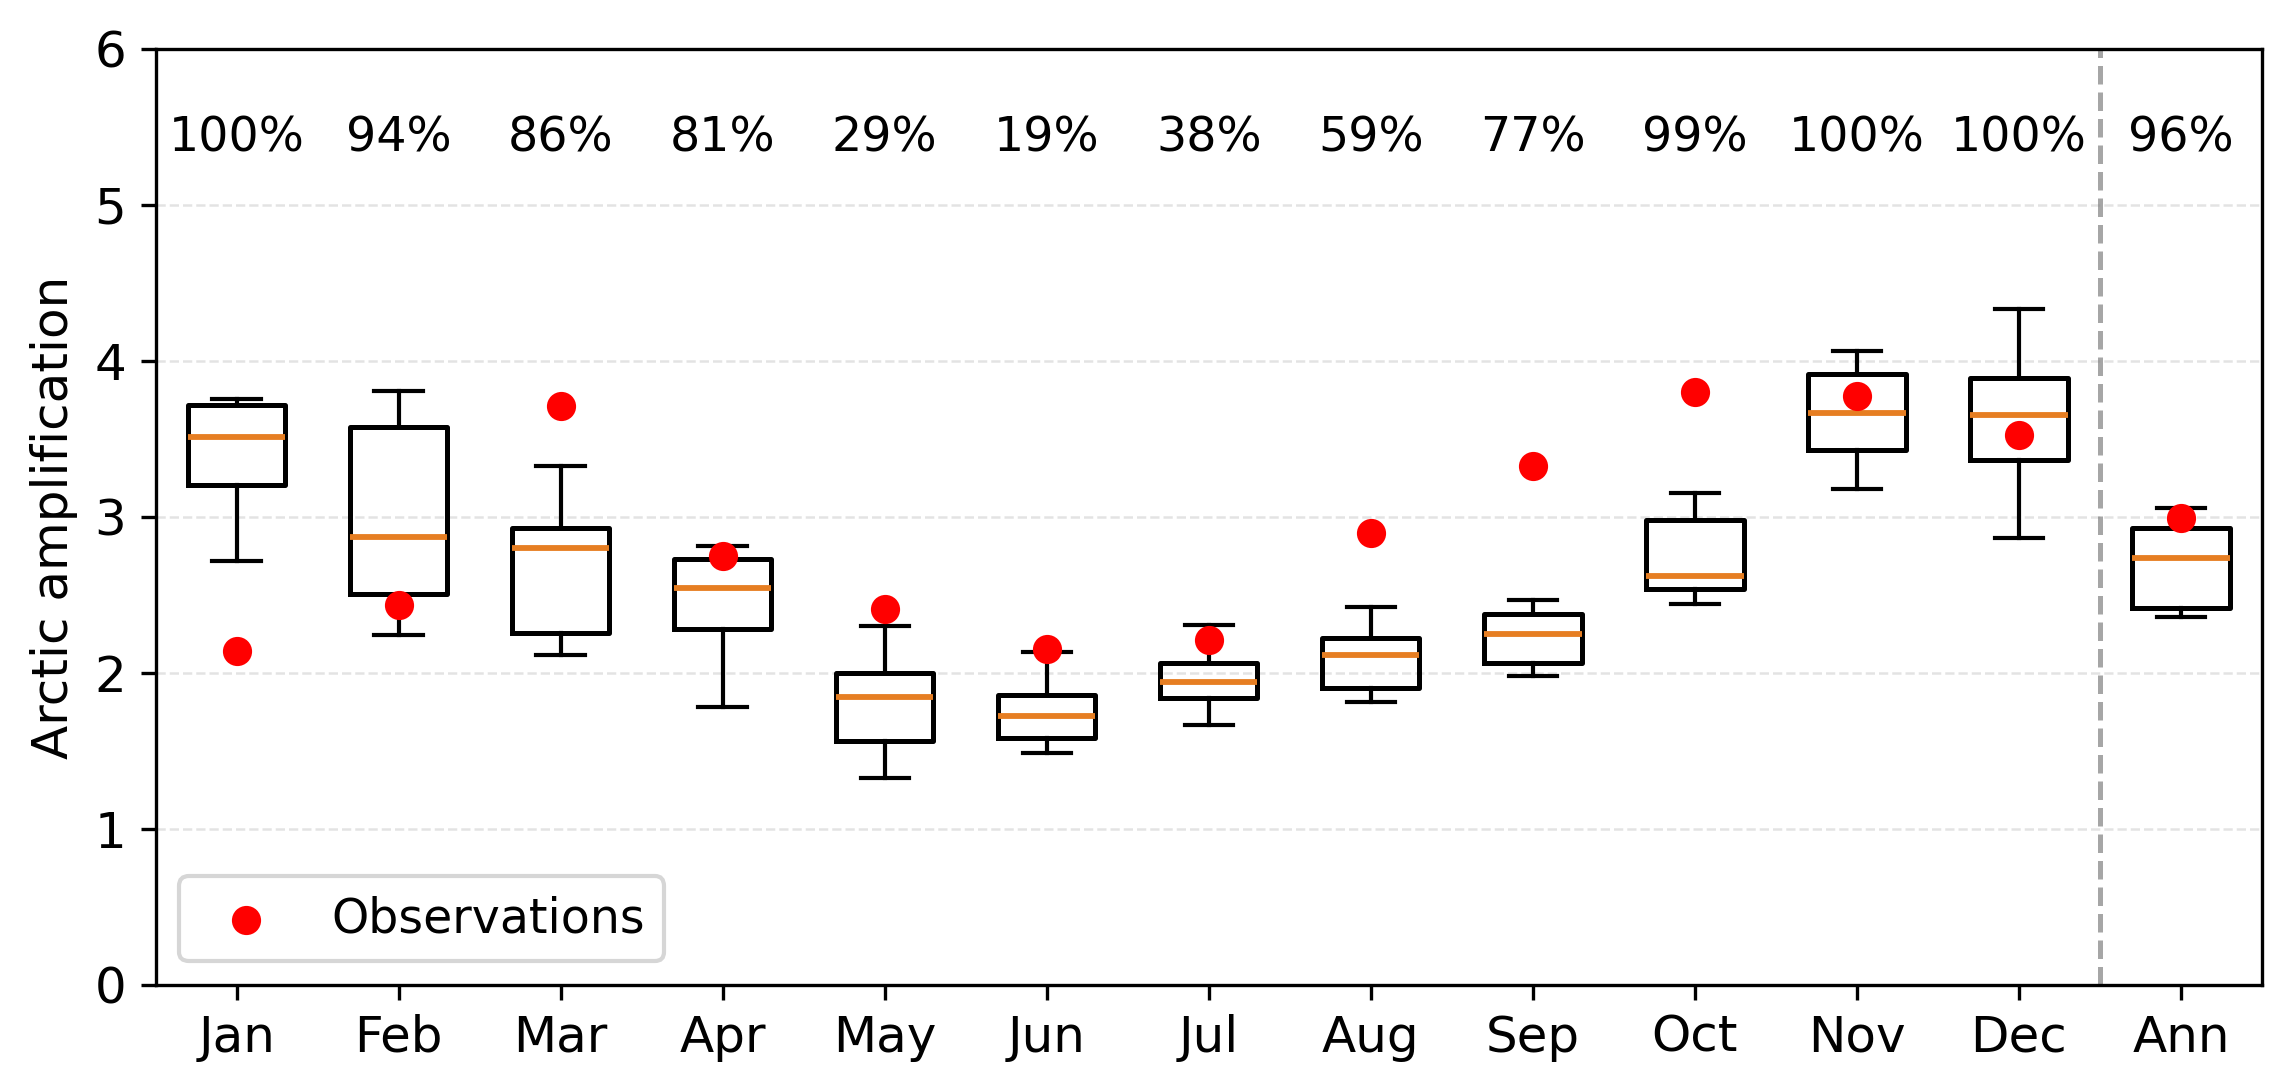

In [21]:
if __name__ == "__main__":
    # ----------------------------------------------------------------------
    # Configuration
    # ----------------------------------------------------------------------
    TOP_DIR = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    OUT_DIR = f"{TOP_DIR}/figure_data"
    FIG_DIR = str(FIG_DIR_ROOT)
    os.makedirs(FIG_DIR, exist_ok=True)

    # Input: monthly diagnostics written by ArcticAAMonthlyMetrics.save_netcdf_metrics()
    nc_path = f"{OUT_DIR}/AA_monthly_metrics_1979-2018.nc"
    out_fig = os.path.join(FIG_DIR, "AA_monthly_boxpanel.center.pdf")
    
    ylim=(0, 6)
    show_grid=True
    show_legend=True
    median_color="#e67e22"   # orange median line
    dot_size=36              # red ERA5 dots
    pct_y_offset=0.07        # move % labels slightly below top
    legend_loc= "lower left"
    
    # ----------------------------------------------------------------------
    # Plot
    # ----------------------------------------------------------------------
    plotter = AAMonthlyBoxplotPlotter(fig_dir=FIG_DIR, fontz=12, dpi=300)

    fig, ax = plotter.plot_from_nc(
        nc_path,
        out_name=os.path.basename(out_fig),
        ylim=ylim,
        show_grid=show_grid,
        show_legend=show_legend,
        median_color=median_color,   # orange median line
        dot_size=dot_size,              # red ERA5 dots
        legend_loc= legend_loc,
        pct_y_offset=pct_y_offset,        # move % labels slightly below top
    )

    print(f"[OK] Figure written to: {out_fig}")
